# 1 Линейная алгебра


## Задача 1
Даны матрицы:  
$$A = \begin{bmatrix}
2 & -4 \\
3 & 5  \\
-1 & 0  
\end{bmatrix} 
, B = \begin{bmatrix}
1 & 2 & 7 \\
-3 & -4 & 0 \\
5 & 2 & 1
\end{bmatrix} 
, C = \begin{bmatrix}
6 & -3 & 9 \\
4 & -5 & 2 \\
8 & 1 & 5
\end{bmatrix}$$

Посчитайте матрицу: $$D = A^TC - 2A^TB^T$$

In [4]:
# autoreload позволяет нам подгружать изменения во внешнем коде
# без необходимости перезагружать kernel у ноутбука
%load_ext autoreload
%autoreload 2

In [2]:
# импорт библиотек
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [6]:
 # Определение матриц A, B и C
A = np.array([[2, -4],
              [3, 5],
              [-1, 0]])

B = np.array([[1, 2, 7],
              [-3, -4, 0],
              [5, 2, 1]])

C = np.array([[6, -3, 9],
              [4, -5, 2],
              [8, 1, 5]])

# Транспонирование матриц A и B
A_T = A.T
B_T = B.T

# Вычисление произведений A^T C и A^T B^T
A_T_C = np.dot(A_T, C)
A_T_B_T = np.dot(A_T, B_T)

# Вычисление матрицы D
D = A_T_C - 2 * A_T_B_T

print("Матрица D:\n", D)

Матрица D:
 [[ 14  14 -11]
 [-16   3  -6]]


## Задача 2
Дано выражение: 
$$3\cdot \begin{bmatrix}
x & 2 & 3 \\
-1 & y & 4
\end{bmatrix} + 
2\cdot \begin{bmatrix}
1 & 2 & -5 \\
2 & -6 & z
\end{bmatrix} = 
\begin{bmatrix}
8 & \upsilon & -1 \\
1 & 6 & 4
\end{bmatrix}$$
Найдите значения $ x, y, z, \upsilon$, при которых выражение верно.

In [14]:
# Определение переменных
x, y, z, v = sp.symbols('x y z v')

# Задание матриц
A = sp.Matrix([[x, 2, 3],
            [-1, y, 4]])

B = sp.Matrix([[1, 2, -5],
            [2, -6, z]])

C = sp.Matrix([[8, v, -1],
            [1, 6, 4]])

# Составление уравнения
equation = sp.Eq(3 * A + 2 * B, C)

# Решение системы уравнений
solution = sp.solve(equation, (x, y, z, v))

# Вывод решения
for i in symbols('x y z v'):
    print (f"{i} = {solution[i]}")

x = 2
y = 6
z = -4
v = 10


## Задача 3
Относительно канонического (стандартного) базиса в $\mathbb{R}^2$ даны три вектора $a_{1} = (2,-5)^T, a_{2} = (-1,3)^T, x = (1,-4)^T$. Примите векторы $a_{1}, a_{2}$ за новый базис $B$, предварительно проверив, что они линейно независимы.
-  Найдите координаты $\left[ x \right]_{B}$ вектора $x$ в новом базисе.
-  Предположим, что координаты вектора $y$ в базисе $B$ заданы $\left[ y \right]_{B} = (1,1)^T$. Найдите координаты вектора $y$ в стандартном базисе.


In [9]:
# Определение строковых векторов
a1_str = np.array([2, -5])
a2_str = np.array([-1, 3])
x_str = np.array([1, -4])

# Преобразование строковых векторов в столбцовые
a1 = a1_str.reshape(-1, 1)
a2 = a2_str.reshape(-1, 1)
x = x_str.reshape(-1, 1)

# 1. Проверка линейной независимости векторов a1 и a2
matrix_A = np.hstack((a1, a2))
det_A = np.linalg.det(matrix_A)

if det_A != 0:
    print("Векторы a1 и a2 линейно независимы и образуют базис B.")
else:
    print("Векторы a1 и a2 линейно зависимы и не могут образовать базис B.")

# 2. Нахождение координат [x]_B вектора x в базисе B
# Решение системы A * [c1, c2]^T = x
c = np.linalg.solve(matrix_A.T, x)
c1, c2 = c[0][0], c[1][0]
print(f"Координаты вектора x в базисе B: c1 = {c1}, c2 = {c2}")

# 3. Преобразование координат вектора y из базиса B в стандартный базис
y_B = np.array([1, 1]).reshape(-1, 1)
y_standard = np.dot(matrix_A, y_B)
print(f"Вектор y в стандартном базисе: {y_standard.T[0]}")

Векторы a1 и a2 линейно независимы и образуют базис B.
Координаты вектора x в базисе B: c1 = -17.0, c2 = -7.0
Вектор y в стандартном базисе: [ 1 -2]


## Задача 4
Исследовательское задание: малоранговая аппроксимация матрицы. Сгенерируйте случайную квадратную матрицу $A \in \mathbb{R}^{n\times n}, n\ge 100$. Выполните сингулярное разложение этой матрицы, и получите три матрицы: $U,S,V^T$. Выполняйте аппроксимацию матрицы A с рангом $r$ меняя его значение, например,от 2 до $n$:
$$\widetilde{A} = U[:, : r]S[:r,:r]V^T[:r,:],$$
и каждый раз считайте ошибку апроксимации (как восстановленная матрица отличается от исходной):
$$E(r)=\left\| A-\widetilde{A} \right\|_{F}=\sqrt{\sum_{i = 1}^{n}\sum_{j = 1}^{n}(a_{ij}-\widetilde{a}_{ij})^2}.$$
Используя библиотеку $matplotlib$, постройте график зависимости ошибки аппроксимации матрицы от ранга $r$.

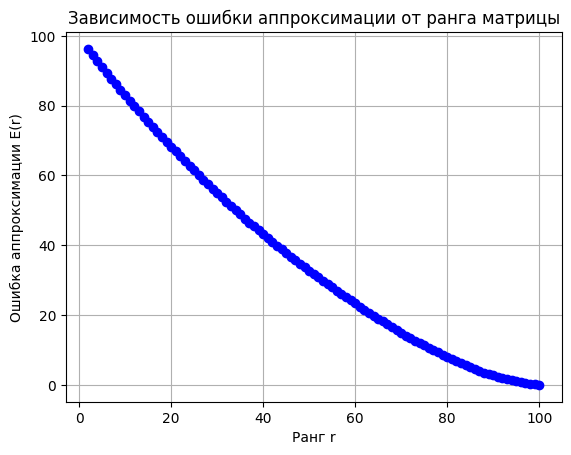

In [11]:
# 1. Генерация случайной матрицы A размером n x n
n = 100  # Размерность матрицы
A = np.random.randn(n, n)

# 2. Сингулярное разложение матрицы A
U, S, Vt = np.linalg.svd(A)

# 3. Аппроксимация матрицы A с разным рангом r и вычисление ошибки
errors = []
for r in range(2, n + 1):
    # Создание диагональной матрицы S_r размером r x r
    S_r = np.diag(S[:r])
    # Аппроксимация матрицы A с рангом r
    A_r = U[:, :r] @ S_r @ Vt[:r, :]
    # Вычисление ошибки аппроксимации E(r) как нормы Фробениуса разности A и A_r
    error = np.linalg.norm(A - A_r, 'fro')
    errors.append(error)

# 4. Построение графика зависимости ошибки от ранга
plt.plot(range(2, n + 1), errors, marker='o', linestyle='-', color='b')
plt.xlabel('Ранг r')
plt.ylabel('Ошибка аппроксимации E(r)')
plt.title('Зависимость ошибки аппроксимации от ранга матрицы')
plt.grid(True)
plt.show()

# 2 Начала мат.анализа и оптимизации

## Задача 1
Посчитайте градиент следующей функции:
$$f(x) = x^3_{1}-2x_{1}x_{2}+x^2_{2}-3x_{1}-2x_{2}, x\in \mathbb{R}^2.$$
Найдите критические точки $x_{c}$ , такие что $\nabla f(x_{c}) = 0.$

In [22]:
sp.init_printing(use_latex='mathjax')
# Определение переменных
x1, x2 = sp.symbols('x1 x2')

# Определение функции f(x)
f = x1 ** 3 - 2 * x1 * x2 + x2 ** 2 - 3 * x1 - 2 * x2

# Вычисление градиента функции f
grad_f = sp.Matrix([sp.diff(f, var) for var in (x1, x2)])

# Нахождение критических точек, решая систему уравнений grad_f = 0
critical_points = sp.solve(grad_f, (x1, x2))

# Вывод результатов
print("Градиент функции f(x):")
sp.pprint(grad_f, use_unicode=True)
print("\nКритические точки функции f(x):")
for point in critical_points:
    print(f"x1 = {point[0]}, x2 = {point[1]}")

Градиент функции f(x):
⎡    2           ⎤
⎢3⋅x₁  - 2⋅x₂ - 3⎥
⎢                ⎥
⎣-2⋅x₁ + 2⋅x₂ - 2⎦

Критические точки функции f(x):
x1 = -1, x2 = 0
x1 = 5/3, x2 = 8/3


## Задача 2
Проверьте, что функция $f=ln(\sqrt{x_{1}}+\sqrt{x_{2}})$ удовлетворяет уравнению:
$$x_{1}\frac{\partial f}{\partial x_{1}}+x_{2}\frac{\partial f}{\partial x_{2}}=\frac{1}{2}.$$

In [3]:
# Определение переменных
x1, x2 = sp.symbols('x1 x2')

# Определение функции f(x)
f = sp.ln(sp.sqrt(x1) + sp.sqrt(x2))

# Вычисление частных производных
df_dx1 = sp.diff(f, x1)
df_dx2 = sp.diff(f, x2)

# Вычисление выражения x1 * df/dx1 + x2 * df/dx2
expression = x1 * df_dx1 + x2 * df_dx2

# Упростить выражение
simplified_expression = sp.simplify(expression)

# Проверка равенства 1/2
is_equal = simplified_expression.equals(1 / 2)

# Вывод результатов
print("Частные производные:")
print(f"df/dx1 = {df_dx1}")
print(f"df/dx2 = {df_dx2}")
print("\nВыражение x1 * df/dx1 + x2 * df/dx2:\n",simplified_expression)
print("\nРавно ли выражение 1/2?\n",is_equal)

Частные производные:
df/dx1 = 1/(2*sqrt(x1)*(sqrt(x1) + sqrt(x2)))
df/dx2 = 1/(2*sqrt(x2)*(sqrt(x1) + sqrt(x2)))

Выражение x1 * df/dx1 + x2 * df/dx2:
 1/2

Равно ли выражение 1/2?
 True


## Задача 3
Предположим, задана функция $f : \mathbb{R}^3\to  \mathbb{R}:$
$$f(x,y,z)=x+y+z+(xyz)^2.$$
Найдите вектор градиента функции $f$, и его численное значение в точке $\upsilon = (1,2,3)^T.$

In [6]:
# 1. Определение символьных переменных
x, y, z = sp.symbols('x y z')

# 2. Определение функции f(x, y, z)
f = x + y + z + (x * y * z) ** 2

# 3. Вычисление частных производных (компонентов градиента)
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)
df_dz = sp.diff(f, z)

# 4. Формирование вектора градиента
gradient_f = sp.Matrix([df_dx, df_dy, df_dz])

# 5. Вычисление значения градиента в точке v = (1, 2, 3)
gradient_at_v = gradient_f.subs({x: 1, y: 2, z: 3})

# Вывод результатов
print("Вектор градиента функции f:\n")
sp.pprint(gradient_f, use_unicode=True)
print("\nЗначение градиента в точке v = (1, 2, 3):\n")
sp.pprint(gradient_at_v, use_unicode=True)

Вектор градиента функции f:

⎡     2  2    ⎤
⎢2⋅x⋅y ⋅z  + 1⎥
⎢             ⎥
⎢   2    2    ⎥
⎢2⋅x ⋅y⋅z  + 1⎥
⎢             ⎥
⎢   2  2      ⎥
⎣2⋅x ⋅y ⋅z + 1⎦

Значение градиента в точке v = (1, 2, 3):

⎡73⎤
⎢  ⎥
⎢37⎥
⎢  ⎥
⎣25⎦


## Задача 4
(Куб Евклидовой нормы). Найти первый дифференциал $df(x)$, а также градиент $\nabla f(x)$ функции:
$$f(x)=\frac{1}{3}\left\| x \right\|^3_{2}, x\in \mathbb{R}^n\text{\\{0}}.$$

In [8]:
# Определение символьных переменных
n = 3  # Размерность пространства (например, R^3)
x = sp.Matrix([sp.symbols(f'x{i + 1}') for i in range(n)]) # Создание вектора переменных x1, x2, ..., xn

# Вычисление Евклидовой нормы ||x||
norm_x = sp.sqrt(x.dot(x))

# Определение функции f(x)
f = (1 / 3) * norm_x ** 3

# Вычисление градиента функции f
gradient_f = sp.Matrix([sp.diff(f, xi) for xi in x])

# Определение приращения dx
dx = sp.Matrix([sp.symbols(f'dx{i + 1}') for i in range(n)])

# Вычисление первого дифференциала df(x)
df = gradient_f.dot(dx)

# Вывод результатов
print("Градиент функции f(x):\n")
sp.pprint(gradient_f)
print("\nПервый дифференциал df(x):\n")
sp.pprint(df)

Градиент функции f(x):

⎡          _________________⎤
⎢         ╱   2     2     2 ⎥
⎢1.0⋅x₁⋅╲╱  x₁  + x₂  + x₃  ⎥
⎢                           ⎥
⎢          _________________⎥
⎢         ╱   2     2     2 ⎥
⎢1.0⋅x₂⋅╲╱  x₁  + x₂  + x₃  ⎥
⎢                           ⎥
⎢          _________________⎥
⎢         ╱   2     2     2 ⎥
⎣1.0⋅x₃⋅╲╱  x₁  + x₂  + x₃  ⎦

Первый дифференциал df(x):

              _________________                 _________________              ↪
             ╱   2     2     2                 ╱   2     2     2               ↪
1.0⋅dx₁⋅x₁⋅╲╱  x₁  + x₂  + x₃   + 1.0⋅dx₂⋅x₂⋅╲╱  x₁  + x₂  + x₃   + 1.0⋅dx₃⋅x₃ ↪

↪     _________________
↪    ╱   2     2     2 
↪ ⋅╲╱  x₁  + x₂  + x₃  


## Задача 5
(Квадрат Евклидовой нормы). Найти первый дифференциал $df(x)$, а также градиент $\nabla f(x)$ функции:
$$f(x)=\left\| A_{x} \right\|^2_{2}, x\in \mathbb{R}^n\text{\\{0}}, A\in \mathbb{R}^{m\times n}.$$

In [9]:
# Размерности
n = 3  # Размерность вектора x
m = 2  # Количество строк в матрице A

# Генерация случайной матрицы A размером m x n и вектора x размером n
A = np.random.randn(m, n)
x = np.random.randn(n)

# Вычисление функции f(x)
f_x = np.linalg.norm(np.dot(A, x)) ** 2

# Вычисление градиента
gradient_f_x = 2 * np.dot(A.T, np.dot(A, x))

# Определение приращения dx
dx = np.random.randn(n)

# Вычисление первого дифференциала
df_x = np.dot(gradient_f_x, dx)

print("Значение функции f(x):", f_x)
print("Градиент функции f(x):", gradient_f_x)
print("Первый дифференциал df(x):", df_x)

Значение функции f(x): 10.24707744400042
Градиент функции f(x): [-7.92902243 -2.5329847  -0.96405414]
Первый дифференциал df(x): -2.852773694499288
